# 01 – Data Understanding: California Housing

Goal: understand the dataset before building any model.

## 1. Setup

### 1.1 Check the Python version
`assert` checks a rule. If the rule is false, the notebook stops with an error.
Here the rule is: Python must be 3.7 or newer.
This way an old Python fails now, at the start, instead of breaking code later.

In [1]:
import sys

assert sys.version_info >= (3, 7)

### 1.2 Check the scikit-learn version and import matplotlib
- `sklearn` = scikit-learn, the ML library we use to build models.
- Some functions we use only exist in version 1.0.1 or newer, so we check that here.
- `version.parse` turns a version text like "1.0.1" into something Python can compare correctly.
- `matplotlib.pyplot` (short name `plt`) is used to draw charts.

In [2]:
from packaging import version
import sklearn
import matplotlib.pyplot as plt

assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

### 1.3 Import pandas and Path
- `pandas` (short name `pd`) works with tables of data, called DataFrames: rows and columns, like Excel.
- `Path` handles file and folder paths. It works the same on Windows and Mac/Linux,
  so the code also runs on GitHub's computer (CI). We use it later to save files.

In [3]:
import pandas as pd
from pathlib import Path

### 1.4 Import NumPy
- `numpy` (short name `np`) does fast maths on lists of numbers (arrays).
- pandas and scikit-learn are built on top of NumPy.
- We need it directly later, e.g. for gradient descent in notebook 02.

In [4]:
import numpy as np

## 2. Load the data

### 2.1 Get the California Housing dataset
- The data comes from scikit-learn. The first run downloads it once and saves it on the PC.
- `as_frame=True` gives it as a pandas table (DataFrame) instead of plain NumPy arrays.
- Each row = **one area** (neighbourhood) in California, not one house.
- Target `MedHouseVal` = the middle house price in that area, in **100,000 USD** (2.5 = $250,000).
- `head()` shows the first 5 rows.

In [5]:
from sklearn.datasets import fetch_california_housing

data = fetch_california_housing(as_frame=True)
df = data.frame
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


### 2.2 What the columns mean
| Column | Meaning |
|---|---|
| `MedInc` | middle income in the area (in 10,000 USD; 3.5 = $35,000) |
| `HouseAge` | middle age of the houses (years) |
| `AveRooms` | average rooms per home |
| `AveBedrms` | average bedrooms per home |
| `Population` | number of people living in the area |
| `AveOccup` | average people per home |
| `Latitude` | north–south position |
| `Longitude` | east–west position |
| `MedHouseVal` | **target**: middle house price (in 100,000 USD) |

The first 8 columns are the **features** (inputs). `MedHouseVal` is the **target** (what we predict).

### 2.3 Size, data types and missing values
`info()` shows:
- how many rows and columns there are
- the type of each column (`float64` = decimal number)
- the **Non-Null Count**: how many values are filled in. If it is lower than the number of rows, values are missing.

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


**Findings:**
- Rows: Considering the above output there are 20640 entries or rows and   Columns: there are 9 Columns
- Missing values: There are no missing values
- Data types: and all data types are same float64

### 2.4 Basic statistics
`describe()` shows, for each column:
- `mean` = average
- `min` / `max` = smallest / biggest value
- `25%` / `50%` / `75%`: 25% of the values are below the `25%` number, and so on. `50%` = the middle value (median).

We use it to spot strange values, e.g. a `max` that is much bigger than the `75%` value.

In [7]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


You spotted the right column ✅. Its max (5.0) is far above the 75% value (2.6).

One thing to fix: it's not a normal outlier. Look at the exact number: 5.00001, which means $500,001. That is too round to be a coincidence.

What it really is: a cap (upper limit). When the data was collected, every price above $500,000 was written down as $500,001. So a $900,000 area and a $2,000,000 area both show 5.00001. The real price is hidden.

Why it matters: the model learns "prices never go above 5", so it can't predict expensive areas correctly.

In [8]:
(df["MedHouseVal"] >= 5).sum()

np.int64(992)

**Finding: price cap**
- What: prices above $500,000 were cut off and saved as 5.00001 ($500,001), so the real price of expensive areas is hidden.
- How many rows: 992 rows, about 5% of the data.
- Why it is a problem: the model only learns prices up to 5, so it will predict too low for expensive houses.
- What we do: keep the rows, write it as a limitation in the README, and check these rows again in error analysis (notebook 05).

### 2.5 Outliers
An outlier is a value very far from the rest.
`AveOccup`: 75% of areas have ≤ 3.3 people per home, but the max is 1,243.
Below we look at the areas with more than 50 people per home.

In [10]:
df[df["AveOccup"] > 50]

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
3364,5.5179,36.0,5.142857,1.142857,4198.0,599.714286,40.41,-120.51,0.675
9172,4.2391,5.0,5.123810,0.933333,8733.0,83.171429,34.47,-118.59,1.546
12104,1.6250,8.0,7.600000,0.950000,1275.0,63.750000,33.97,-117.33,1.625
13034,6.1359,52.0,8.275862,1.517241,6675.0,230.172414,38.69,-121.15,2.250
16420,5.7485,26.0,5.366667,0.900000,1542.0,51.400000,37.89,-121.29,1.625
16669,4.2639,46.0,9.076923,1.307692,6532.0,502.461538,35.32,-120.70,3.500
19006,10.2264,45.0,3.166667,0.833333,7460.0,1243.333333,38.32,-121.98,1.375


**Finding: AveOccup outliers**
- What: some areas have more than 50 people per home (max 1,243), while 75% of areas have 3.3 or fewer.
- How many rows: 7 out of 20,640, a very small number.
- Likely reason: e.g. row 19006 has 7,460 people in about 6 homes (7,460 ÷ 1,243), so it is probably a prison or a hostel, not normal housing.
- What we do: keep them, since 7 rows hardly affect the model, and note them as a limitation.

### 2.6 Histograms
A histogram puts the values of a column into buckets (bins) and draws one bar per bucket.
Tall bar = many areas have values in that range.
`bins=50` = 50 buckets per chart. `figsize` = the size of the picture.

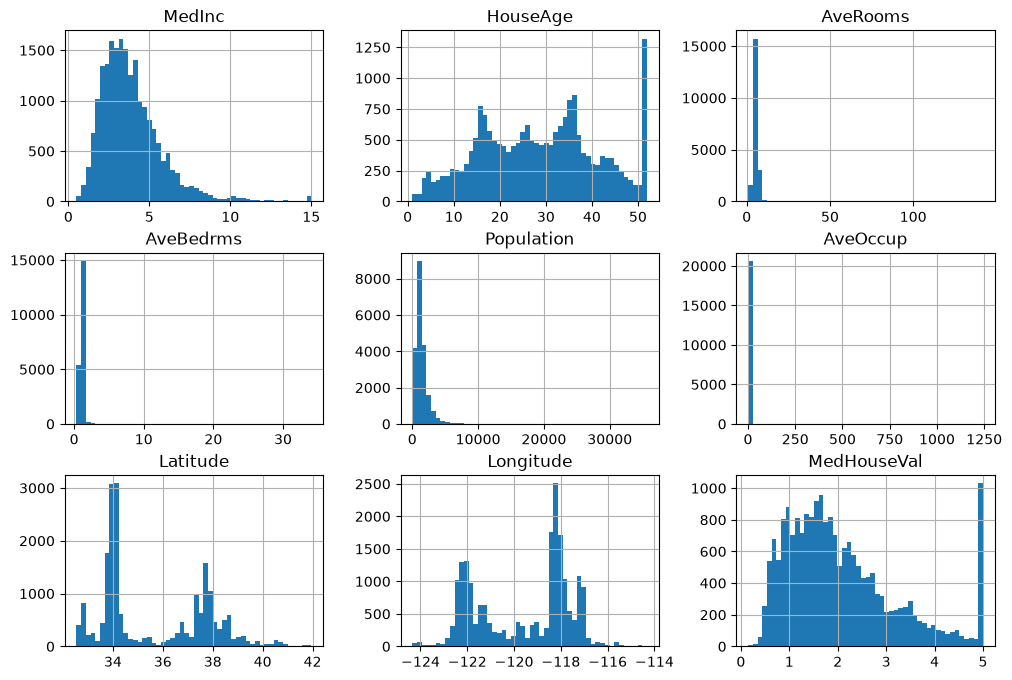

In [11]:
df.hist(bins=50, figsize=(12, 8))
plt.show()

In [12]:
(df["HouseAge"] == 52).sum()

np.int64(1273)

**Finding: HouseAge cap**
- What: the histogram shows a tall bar at 52, so all houses aged 52+ were saved as 52.
- How many rows: 1,273 (about 6%).
- Why it matters less than the price cap: it is a feature, not the target, so the model can still predict the price; it just can't tell "52 years" from "very old".
- What we do: keep the rows and note it as a limitation.

### 2.7 Correlation with the target
Correlation = a number from -1 to 1 showing how strongly a feature moves together with the price.
Close to 1 = strong positive, close to -1 = strong negative, close to 0 = weak.
Below: each feature's correlation with `MedHouseVal`, sorted from strongest to weakest.

In [13]:
df.corr()["MedHouseVal"].sort_values(ascending=False)

MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64

**Finding: correlation**
- Strongest: `MedInc` (0.69) — higher income area → higher house price.
- All other features are weak (between -0.15 and 0.15).
- Careful: correlation only measures straight-line links. Location (Latitude/Longitude) looks weak
  but probably matters a lot (coast vs inland). Low correlation ≠ useless.
- What we do: keep all 8 features.

## 3. Train/test split
- `X` = the 8 features (inputs), `y` = `MedHouseVal` (the target).
- 80% train (the model learns from it), 20% test (kept hidden to check the model on unseen data).
- `random_state=42` = the same split every run, so results can be reproduced.

In [14]:
from sklearn.model_selection import train_test_split

X = df.drop(columns="MedHouseVal")
y = df["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(X_train.shape, X_test.shape)

(16512, 8) (4128, 8)


### 3.1 Leakage (what to avoid)
Leakage = the model gets the answer, or info from the test set, during training.
It looks perfect in testing but fails on real new data.
In this project:
1. Never keep `MedHouseVal` as a feature when predicting `expensive`, because `expensive` is made from it.
2. Never use the test set to choose models or settings; only use it once at the end.